
# Navier–Stokes PINNsFormer：Adam Simple-Sum vs Adam + ConFIG 完整结果分析

这个 notebook 用于**不重新训练模型**的结果复盘，包含：

- 读取两个训练历史文件（当前实验实际保存为 `.npz`；也兼容保存字典的 `.npy`）。
- 打印 Adam Simple-Sum 与 Adam + ConFIG 的训练参数/最终 loss/平均 loss/gradient norm/cosine/conflict rate 对比。
- 重新加载两个 `.pt` checkpoint，使用**相同且正确的评估定义**计算 `u / v / p` Relative L2。
- 计算 `MAE / Max Absolute Error`。
- 分别绘制 Adam 与 ConFIG 的 `u / v / p` **Absolute Error** 空间图，并对同一物理量使用相同的色标范围，便于公平比较。
- 额外计算 pressure mean-aligned Relative L2，用于检查不可压 Navier–Stokes 中 pressure 常数偏置（gauge freedom）的影响。
- 绘制 loss、gradient norm、cosine 等训练过程对比曲线。

> **重要修正**
>
> 之前两个训练 notebook 的 evaluation cell 中，`truth[name]` 的形状是 `(N, 1)`，而 `pred` 被压成了 `(N,)`。直接执行 `truth[name] - pred` 会触发 NumPy broadcasting，生成 `(N, N)` 的差值矩阵，因此之前打印的 Relative L2 **不能作为最终公平结果**。
>
> 本 notebook 在计算所有测试指标前显式执行 `.reshape(-1)`，保证 true/pred 都是 `(N,)`。后续以这里重新计算的 L2 为准。

本 notebook **不会运行 1000-step training loop**，只读取 history 和已保存 checkpoint。


In [1]:

from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Python :", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


Python : /home/simplexity/anaconda3/envs/config_pinn/bin/python
PyTorch: 2.5.1+cu121
CUDA   : 12.1
CUDA available: True
GPU    : NVIDIA GeForce GTX 1080 Ti


## 1. 路径与实验元数据

In [2]:

# ===== 只需要在服务器目录不同的时候修改这一格 =====

PINNSFORMER_ROOT = Path(
    os.environ.get("PINNSFORMER_ROOT", "/home/simplexity/cyt/pinnsformer-main")
)

EXPERIMENT_ROOT = Path(
    os.environ.get(
        "PINNSFORMER_CONFIG_ROOT",
        str(PINNSFORMER_ROOT / "pinnsformer-config"),
    )
)

DATA_PATH = PINNSFORMER_ROOT / "demo" / "navier_stokes" / "cylinder_nektar_wake.mat"

BASELINE_HISTORY = EXPERIMENT_ROOT / "outputs" / "navier_stokes_adam_baseline" / "ns_pinnsformer_adam_sum_history.npz"
CONFIG_HISTORY = EXPERIMENT_ROOT / "outputs" / "navier_stokes_config" / "ns_pinnsformer_config_2loss_history.npz"

BASELINE_MODEL = EXPERIMENT_ROOT / "outputs" / "navier_stokes_adam_baseline" / "ns_pinnsformer_adam_sum.pt"
CONFIG_MODEL = EXPERIMENT_ROOT / "outputs" / "navier_stokes_config" / "ns_pinnsformer_config_2loss.pt"

OUTPUT_DIR = EXPERIMENT_ROOT / "outputs" / "comparison_adam_vs_config"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 这些值来自本次已经完成的两个训练 notebook 配置/终端输出，
# 不是从 history.npz 中读取的。若以后重跑，请同步更新。
EXPERIMENT_META = {
    "seed": 0,
    "n_train": 800,
    "num_step": 5,
    "time_step": 1e-2,
    "optimizer_steps": 1000,
    "learning_rate": 1e-4,
    "model_params": 454106,
    "snapshot": 100,
}

RUN_META = {
    "Adam Simple-Sum": {
        "wall_time_s": 642.24,
        "peak_vram_mib": 8535.08,
    },
    "Adam + ConFIG": {
        "wall_time_s": 674.29,
        "peak_vram_mib": 7671.19,
    },
}

print("PINNSFORMER_ROOT :", PINNSFORMER_ROOT)
print("EXPERIMENT_ROOT  :", EXPERIMENT_ROOT)
print("DATA_PATH        :", DATA_PATH)
print("BASELINE_HISTORY :", BASELINE_HISTORY)
print("CONFIG_HISTORY   :", CONFIG_HISTORY)
print("BASELINE_MODEL   :", BASELINE_MODEL)
print("CONFIG_MODEL     :", CONFIG_MODEL)
print("OUTPUT_DIR       :", OUTPUT_DIR)


PINNSFORMER_ROOT : /home/simplexity/cyt/pinnsformer-main
EXPERIMENT_ROOT  : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
DATA_PATH        : /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
BASELINE_HISTORY : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adam_baseline/ns_pinnsformer_adam_sum_history.npz
CONFIG_HISTORY   : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_config/ns_pinnsformer_config_2loss_history.npz
BASELINE_MODEL   : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adam_baseline/ns_pinnsformer_adam_sum.pt
CONFIG_MODEL     : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_config/ns_pinnsformer_config_2loss.pt
OUTPUT_DIR       : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config


## 2. 读取两个 history 文件并检查内容

In [3]:

def load_history(path):
    """Load current .npz history; also supports a .npy file that stores a dict."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"History file not found: {path}")

    obj = np.load(path, allow_pickle=True)

    if isinstance(obj, np.lib.npyio.NpzFile):
        data = {k: np.asarray(obj[k]) for k in obj.files}
        obj.close()
        return data

    # Optional compatibility for np.save(dict)
    if isinstance(obj, np.ndarray) and obj.shape == ():
        maybe_dict = obj.item()
        if isinstance(maybe_dict, dict):
            return {k: np.asarray(v) for k, v in maybe_dict.items()}

    raise ValueError(
        f"Unsupported history format: {path}. "
        "Expected .npz or a scalar .npy containing a dict."
    )


baseline_h = load_history(BASELINE_HISTORY)
config_h = load_history(CONFIG_HISTORY)

required_keys = {
    "step", "total", "data", "physics",
    "g_data_norm", "g_physics_norm",
    "cosine", "conflict",
}

for name, h in [
    ("Adam Simple-Sum", baseline_h),
    ("Adam + ConFIG", config_h),
]:
    missing = required_keys.difference(h.keys())
    if missing:
        raise KeyError(f"{name} missing keys: {sorted(missing)}")

    print(f"\n{name}")
    print("keys :", list(h.keys()))
    print("n    :", len(h["step"]))
    print("steps:", int(h["step"][0]), "->", int(h["step"][-1]))



Adam Simple-Sum
keys : ['step', 'total', 'data', 'physics', 'g_data_norm', 'g_physics_norm', 'cosine', 'conflict']
n    : 101
steps: 0 -> 999

Adam + ConFIG
keys : ['step', 'total', 'data', 'physics', 'g_data_norm', 'g_physics_norm', 'cosine', 'conflict']
n    : 101
steps: 0 -> 999


## 3. 打印训练参数与 history 对比表

In [4]:

meta_df = pd.DataFrame(
    {
        "Adam Simple-Sum": {
            "Backbone": "PINNsFormer",
            "Optimizer": "Adam",
            "LR": EXPERIMENT_META["learning_rate"],
            "Optimizer steps": EXPERIMENT_META["optimizer_steps"],
            "Seed": EXPERIMENT_META["seed"],
            "N_TRAIN": EXPERIMENT_META["n_train"],
            "Pseudo sequence": EXPERIMENT_META["num_step"],
            "Time step": EXPERIMENT_META["time_step"],
            "Model params": EXPERIMENT_META["model_params"],
            "Gradient update": "g_data + g_physics",
            "Wall time (min)": RUN_META["Adam Simple-Sum"]["wall_time_s"] / 60,
            "Peak VRAM (MiB)": RUN_META["Adam Simple-Sum"]["peak_vram_mib"],
        },
        "Adam + ConFIG": {
            "Backbone": "PINNsFormer",
            "Optimizer": "Adam",
            "LR": EXPERIMENT_META["learning_rate"],
            "Optimizer steps": EXPERIMENT_META["optimizer_steps"],
            "Seed": EXPERIMENT_META["seed"],
            "N_TRAIN": EXPERIMENT_META["n_train"],
            "Pseudo sequence": EXPERIMENT_META["num_step"],
            "Time step": EXPERIMENT_META["time_step"],
            "Model params": EXPERIMENT_META["model_params"],
            "Gradient update": "ConFIG(g_data, g_physics)",
            "Wall time (min)": RUN_META["Adam + ConFIG"]["wall_time_s"] / 60,
            "Peak VRAM (MiB)": RUN_META["Adam + ConFIG"]["peak_vram_mib"],
        },
    }
)

display(meta_df)


,Adam Simple-Sum,Adam + ConFIG
Backbone,PINNsFormer,PINNsFormer
Optimizer,Adam,Adam
LR,0.0001,0.0001
Optimizer steps,1000,1000
Seed,0,0
N_TRAIN,800,800
Pseudo sequence,5,5
Time step,0.01,0.01
Model params,454106,454106
Gradient update,g_data + g_physics,"ConFIG(g_data, g_physics)"


In [5]:

def safe_nanmean(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmean(x))

def summarize_history(h):
    step = np.asarray(h["step"])
    late_mask = step >= 700

    return {
        "Final total loss": float(h["total"][-1]),
        "Final data loss": float(h["data"][-1]),
        "Final physics loss": float(h["physics"][-1]),
        "Min total loss": float(np.min(h["total"])),
        "Min data loss": float(np.min(h["data"])),
        "Min physics loss": float(np.min(h["physics"])),
        "Mean total loss": float(np.mean(h["total"])),
        "Mean data loss": float(np.mean(h["data"])),
        "Mean physics loss": float(np.mean(h["physics"])),
        "Final ||g_data||": float(h["g_data_norm"][-1]),
        "Final ||g_physics||": float(h["g_physics_norm"][-1]),
        "Mean cosine": safe_nanmean(h["cosine"]),
        "Sampled conflict rate": safe_nanmean(h["conflict"]),
        "Late mean cosine (step>=700)": safe_nanmean(h["cosine"][late_mask]),
        "Late conflict rate (step>=700)": safe_nanmean(h["conflict"][late_mask]),
    }

summary = pd.DataFrame(
    {
        "Adam Simple-Sum": summarize_history(baseline_h),
        "Adam + ConFIG": summarize_history(config_h),
    }
)

# 对越小越好的量计算 ConFIG 相对 Adam 的改善百分比
lower_is_better_rows = [
    "Final total loss",
    "Final data loss",
    "Final physics loss",
    "Min total loss",
    "Min data loss",
    "Min physics loss",
    "Mean total loss",
    "Mean data loss",
    "Mean physics loss",
]

summary["ConFIG improvement vs Adam (%)"] = np.nan
for row in lower_is_better_rows:
    b = float(summary.loc[row, "Adam Simple-Sum"])
    c = float(summary.loc[row, "Adam + ConFIG"])
    summary.loc[row, "ConFIG improvement vs Adam (%)"] = (b - c) / b * 100.0

display(summary)

summary.to_csv(OUTPUT_DIR / "history_summary.csv")
print("Saved:", OUTPUT_DIR / "history_summary.csv")


,Adam Simple-Sum,Adam + ConFIG,ConFIG improvement vs Adam (%)
Final total loss,0.001381,0.001614,-16.894004
Final data loss,0.000966,0.001254,-29.761104
Final physics loss,0.000415,0.000361,13.058842
Min total loss,0.001381,0.001614,-16.894004
Min data loss,0.000966,0.001254,-29.761104
Min physics loss,0.000415,0.000340,18.103378
Mean total loss,0.021243,0.023100,-8.739783
Mean data loss,0.017202,0.020953,-21.805040
Mean physics loss,0.004041,0.002147,46.872907
Final ||g_data||,0.040937,0.103527,NaN


Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/history_summary.csv


In [6]:

def first_step_below(h, key, threshold):
    values = np.asarray(h[key])
    mask = values < threshold
    if not np.any(mask):
        return np.nan
    return int(np.asarray(h["step"])[np.where(mask)[0][0]])

thresholds = [1e-2, 5e-3, 2e-3, 1e-3, 5e-4]

physics_threshold_df = pd.DataFrame(
    {
        "threshold": thresholds,
        "Adam Simple-Sum step": [
            first_step_below(baseline_h, "physics", t) for t in thresholds
        ],
        "Adam + ConFIG step": [
            first_step_below(config_h, "physics", t) for t in thresholds
        ],
    }
)

display(physics_threshold_df)
physics_threshold_df.to_csv(
    OUTPUT_DIR / "physics_threshold_steps.csv",
    index=False,
)


,threshold,Adam Simple-Sum step,Adam + ConFIG step
0,0.0100,60,30
1,0.0050,160,70
2,0.0020,410,130
3,0.0010,630,170
4,0.0005,900,730


## 4. 训练曲线对比

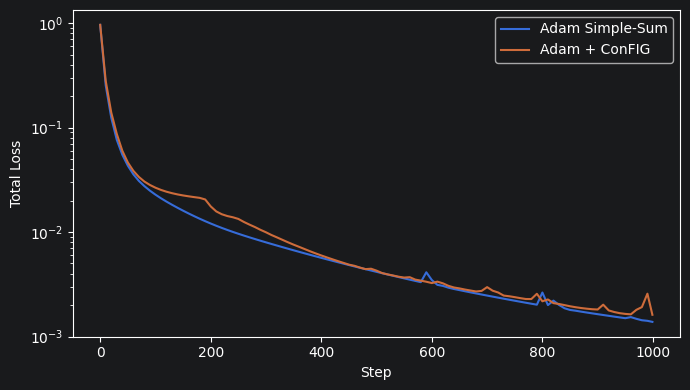

In [7]:

# Total loss
plt.figure(figsize=(7, 4))
plt.semilogy(baseline_h["step"], baseline_h["total"], label="Adam Simple-Sum")
plt.semilogy(config_h["step"], config_h["total"], label="Adam + ConFIG")
plt.xlabel("Step")
plt.ylabel("Total Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "total_loss_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


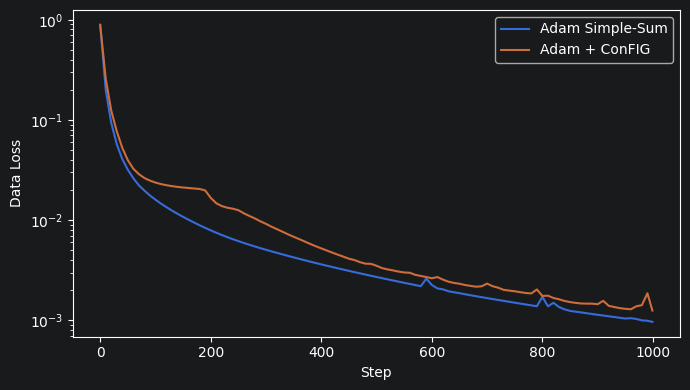

In [8]:

# Data loss
plt.figure(figsize=(7, 4))
plt.semilogy(baseline_h["step"], baseline_h["data"], label="Adam Simple-Sum")
plt.semilogy(config_h["step"], config_h["data"], label="Adam + ConFIG")
plt.xlabel("Step")
plt.ylabel("Data Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_loss_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


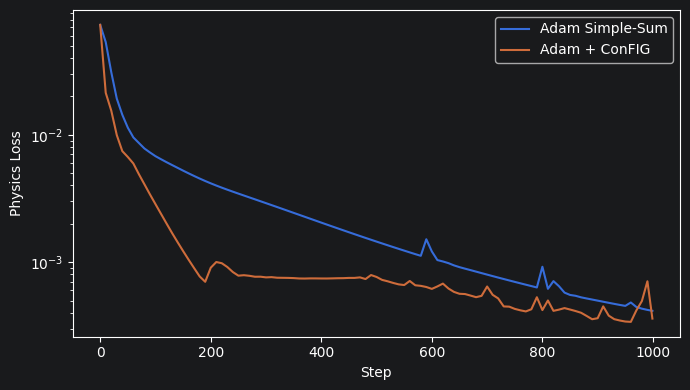

In [9]:

# Physics loss
plt.figure(figsize=(7, 4))
plt.semilogy(baseline_h["step"], baseline_h["physics"], label="Adam Simple-Sum")
plt.semilogy(config_h["step"], config_h["physics"], label="Adam + ConFIG")
plt.xlabel("Step")
plt.ylabel("Physics Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "physics_loss_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


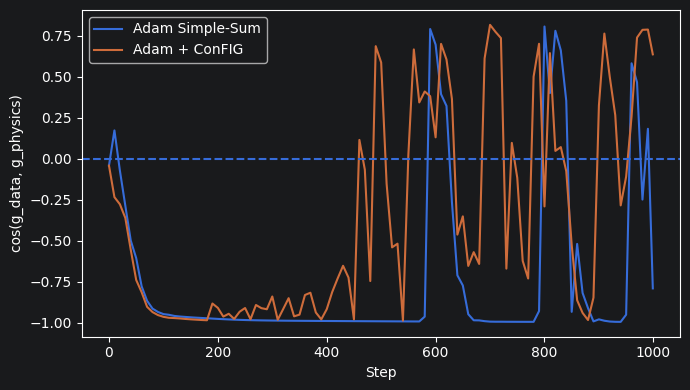

In [10]:

# Gradient cosine
plt.figure(figsize=(7, 4))
plt.plot(baseline_h["step"], baseline_h["cosine"], label="Adam Simple-Sum")
plt.plot(config_h["step"], config_h["cosine"], label="Adam + ConFIG")
plt.axhline(0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("cos(g_data, g_physics)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gradient_cosine_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


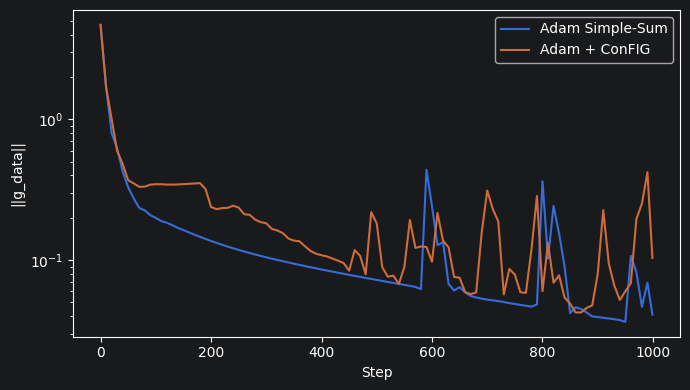

In [11]:

# Data gradient norm
plt.figure(figsize=(7, 4))
plt.semilogy(baseline_h["step"], baseline_h["g_data_norm"], label="Adam Simple-Sum")
plt.semilogy(config_h["step"], config_h["g_data_norm"], label="Adam + ConFIG")
plt.xlabel("Step")
plt.ylabel("||g_data||")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "g_data_norm_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


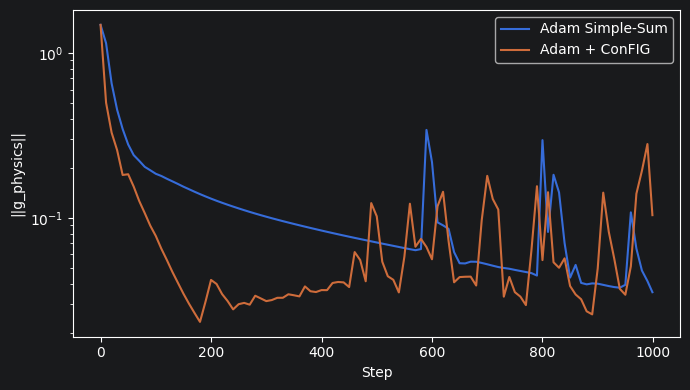

In [12]:

# Physics gradient norm
plt.figure(figsize=(7, 4))
plt.semilogy(baseline_h["step"], baseline_h["g_physics_norm"], label="Adam Simple-Sum")
plt.semilogy(config_h["step"], config_h["g_physics_norm"], label="Adam + ConFIG")
plt.xlabel("Step")
plt.ylabel("||g_physics||")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "g_physics_norm_comparison.png", dpi=200, bbox_inches="tight")
plt.show()



## 5. 加载两个 checkpoint 并重新计算正确的 Relative L2

这里**不重新训练**。

评估严格使用训练时的 stream-function 定义：

$$
u = \frac{\partial \psi}{\partial y},
\qquad
v = -\frac{\partial \psi}{\partial x}.
$$

并且在做误差计算前强制将 `truth` 与 `prediction` 都转换为 `(N,)`，避免 NumPy broadcasting。


In [13]:

# Locate navier_stokes_common.py
common_candidates = [
    EXPERIMENT_ROOT,
    Path.cwd(),
    PINNSFORMER_ROOT / "pinnsformer-config",
]

COMMON_CODE_DIR = None
for candidate in common_candidates:
    if (candidate / "navier_stokes_common.py").exists():
        COMMON_CODE_DIR = candidate
        break

if COMMON_CODE_DIR is None:
    raise FileNotFoundError(
        "Cannot find navier_stokes_common.py. "
        "Set PINNSFORMER_CONFIG_ROOT or run this notebook from pinnsformer-config/."
    )

sys.path.insert(0, str(COMMON_CODE_DIR))

from navier_stokes_common import (
    PINNsformer,
    get_n_params,
    load_training_data,
    evaluation_tensors,
)

for p in [DATA_PATH, BASELINE_MODEL, CONFIG_MODEL]:
    if not Path(p).exists():
        raise FileNotFoundError(p)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Common code:", COMMON_CODE_DIR)
print("Device     :", device)


Common code: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
Device     : cuda:0


In [14]:

# Load reference data. Training batch is created only because the helper returns
# both batch and reference; no training step is performed.
_, reference = load_training_data(
    DATA_PATH,
    device,
    seed=EXPERIMENT_META["seed"],
    n_train=EXPERIMENT_META["n_train"],
    num_step=EXPERIMENT_META["num_step"],
    time_step=EXPERIMENT_META["time_step"],
)

ev, truth_raw = evaluation_tensors(
    reference,
    device,
    snap=EXPERIMENT_META["snapshot"],
    num_step=EXPERIMENT_META["num_step"],
    time_step=EXPERIMENT_META["time_step"],
)

truth = {
    name: np.asarray(value).reshape(-1)
    for name, value in truth_raw.items()
}

print("Truth shapes after flatten:")
for k, v in truth.items():
    print(f"  {k}: {v.shape}")


Truth shapes after flatten:
  u: (5000,)
  v: (5000,)
  p: (5000,)


In [15]:

def load_model(checkpoint_path, device):
    model = PINNsformer(
        d_out=2,
        d_hidden=512,
        d_model=32,
        N=1,
        heads=2,
    ).to(device)

    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model


def predict_uvp(model, ev):
    # We need autograd for u=psi_y and v=-psi_x, so do NOT use torch.no_grad().
    psi_p = model(ev["x"], ev["y"], ev["t"])
    psi = psi_p[:, :, 0:1]
    p_pred = psi_p[:, :, 1:2]

    u_pred = torch.autograd.grad(
        psi,
        ev["y"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=False,
    )[0]

    v_pred = -torch.autograd.grad(
        psi,
        ev["x"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=False,
        create_graph=False,
    )[0]

    return {
        "u": u_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "v": v_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "p": p_pred.detach().cpu().numpy()[:, 0].reshape(-1),
    }


baseline_model = load_model(BASELINE_MODEL, device)
baseline_pred = predict_uvp(baseline_model, ev)
del baseline_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Rebuild evaluation tensors before the second model so that the autograd graph
# is completely independent.
ev2, _ = evaluation_tensors(
    reference,
    device,
    snap=EXPERIMENT_META["snapshot"],
    num_step=EXPERIMENT_META["num_step"],
    time_step=EXPERIMENT_META["time_step"],
)

config_model = load_model(CONFIG_MODEL, device)
config_pred = predict_uvp(config_model, ev2)
del config_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Prediction shapes:")
for method, pred in [
    ("Adam Simple-Sum", baseline_pred),
    ("Adam + ConFIG", config_pred),
]:
    print(method, {k: v.shape for k, v in pred.items()})


/tmp/ipykernel_105758/3138563659.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=device)


Prediction shapes:
Adam Simple-Sum {'u': (5000,), 'v': (5000,), 'p': (5000,)}
Adam + ConFIG {'u': (5000,), 'v': (5000,), 'p': (5000,)}


/tmp/ipykernel_105758/3138563659.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=device)


## 6. 正确 L2、MAE、Max Absolute Error 与 pressure gauge-aligned L2

In [16]:

def relative_l2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    assert y_true.shape == y_pred.shape, (y_true.shape, y_pred.shape)
    return float(np.linalg.norm(y_true - y_pred, 2) / np.linalg.norm(y_true, 2))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))


def max_abs_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.max(np.abs(y_true - y_pred)))


def align_pressure_mean(p_true, p_pred):
    p_true = np.asarray(p_true).reshape(-1)
    p_pred = np.asarray(p_pred).reshape(-1)
    return p_pred - np.mean(p_pred) + np.mean(p_true)


predictions = {
    "Adam Simple-Sum": baseline_pred,
    "Adam + ConFIG": config_pred,
}

rows = []
for method, pred in predictions.items():
    for field in ["u", "v", "p"]:
        row = {
            "Method": method,
            "Field": field,
            "Relative L2": relative_l2(truth[field], pred[field]),
            "MAE": mae(truth[field], pred[field]),
            "Max Absolute Error": max_abs_error(truth[field], pred[field]),
        }

        if field == "p":
            p_aligned = align_pressure_mean(truth["p"], pred["p"])
            row["Mean-aligned Relative L2"] = relative_l2(truth["p"], p_aligned)
        else:
            row["Mean-aligned Relative L2"] = np.nan

        rows.append(row)

field_metrics = pd.DataFrame(rows)
display(field_metrics)

field_metrics.to_csv(
    OUTPUT_DIR / "field_metrics_corrected.csv",
    index=False,
)
print("Saved:", OUTPUT_DIR / "field_metrics_corrected.csv")


,Method,Field,Relative L2,MAE,Max Absolute Error,Mean-aligned Relative L2
0,Adam Simple-Sum,u,0.057218,0.031171,0.411395,NaN
1,Adam Simple-Sum,v,0.162706,0.031579,0.174138,NaN
2,Adam Simple-Sum,p,7.115587,0.944240,1.168361,0.354244
3,Adam + ConFIG,u,0.043878,0.026559,0.281162,NaN
4,Adam + ConFIG,v,0.167616,0.033476,0.177705,NaN
5,Adam + ConFIG,p,0.963713,0.120951,0.423981,0.316694


Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/field_metrics_corrected.csv


In [17]:

# Wide L2 comparison with ConFIG improvement.
l2_wide = field_metrics.pivot(
    index="Field",
    columns="Method",
    values="Relative L2",
)

l2_wide["ConFIG improvement vs Adam (%)"] = (
    (l2_wide["Adam Simple-Sum"] - l2_wide["Adam + ConFIG"])
    / l2_wide["Adam Simple-Sum"]
    * 100.0
)

display(l2_wide)


Method,Adam + ConFIG,Adam Simple-Sum,ConFIG improvement vs Adam (%)
Field,,,
p,0.963713,7.115587,86.456317
u,0.043878,0.057218,23.313802
v,0.167616,0.162706,-3.017759



## 7. Absolute Error 空间图

下面会分别生成：

- `Adam Simple-Sum`: `u / v / p`
- `Adam + ConFIG`: `u / v / p`

同一个物理量的 Adam 与 ConFIG 使用**相同的 `vmin/vmax`**，因此两张图的颜色可以直接横向比较。

原始 Navier–Stokes demo 使用 `50 × 100` reshape，因此这里沿用该网格形状。


In [18]:

GRID_SHAPE = (50, 100)
EXTENT = [-3, 8, -2, 2]

n_points = len(truth["u"])
if np.prod(GRID_SHAPE) != n_points:
    raise ValueError(
        f"GRID_SHAPE={GRID_SHAPE} has {np.prod(GRID_SHAPE)} points, "
        f"but evaluation has {n_points}. Update GRID_SHAPE."
    )

absolute_errors = {
    method: {
        field: np.abs(truth[field] - pred[field])
        for field in ["u", "v", "p"]
    }
    for method, pred in predictions.items()
}

# Use one common error scale per physical variable for fair visual comparison.
error_scales = {}
for field in ["u", "v", "p"]:
    error_scales[field] = max(
        np.max(absolute_errors["Adam Simple-Sum"][field]),
        np.max(absolute_errors["Adam + ConFIG"][field]),
    )

print("Common color scale vmax:")
for field, vmax in error_scales.items():
    print(f"  {field}: {vmax:.6e}")


Common color scale vmax:
  u: 4.113947e-01
  v: 1.777046e-01
  p: 1.168361e+00


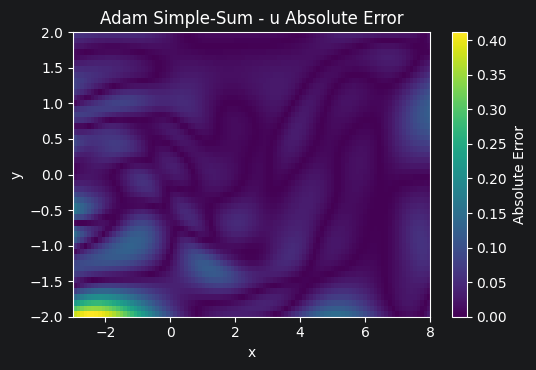

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_simple_sum_u_absolute_error.png


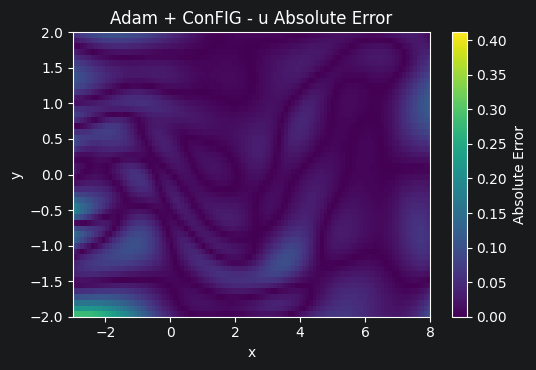

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_plus_config_u_absolute_error.png


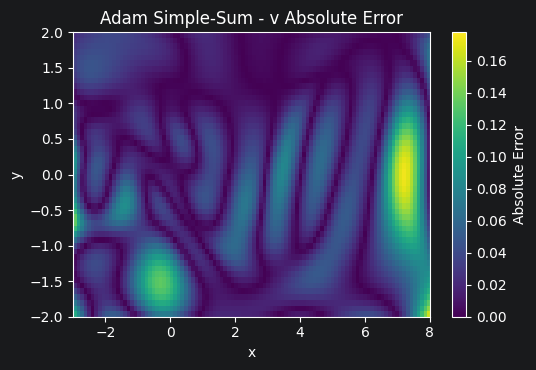

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_simple_sum_v_absolute_error.png


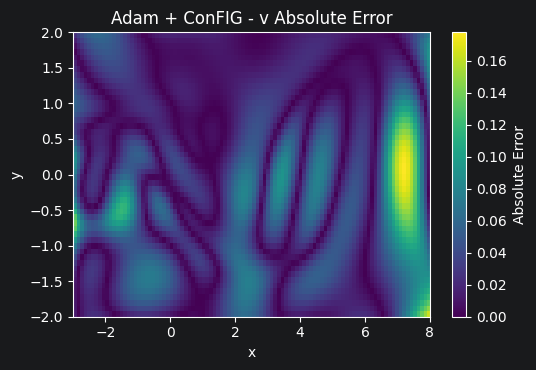

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_plus_config_v_absolute_error.png


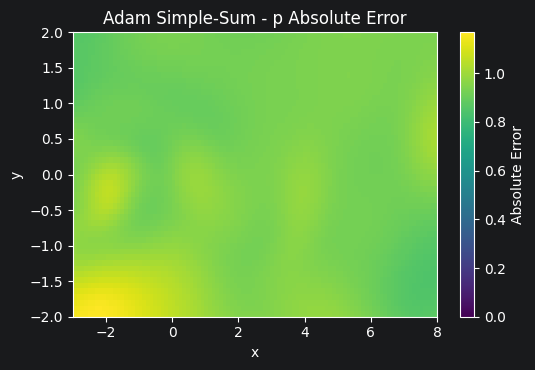

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_simple_sum_p_absolute_error.png


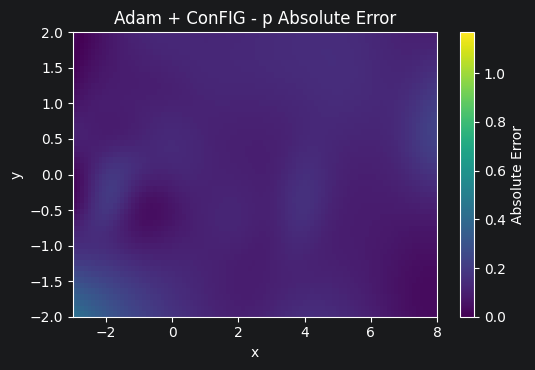

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_plus_config_p_absolute_error.png


In [19]:

def plot_absolute_error(method, field, error, vmax, output_dir):
    plt.figure(figsize=(5.5, 3.8))
    im = plt.imshow(
        error.reshape(GRID_SHAPE),
        extent=EXTENT,
        aspect="auto",
        vmin=0.0,
        vmax=vmax,
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"{method} - {field} Absolute Error")
    plt.colorbar(im, label="Absolute Error")
    plt.tight_layout()

    safe_method = (
        method.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
    )
    out = output_dir / f"{safe_method}_{field}_absolute_error.png"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


for field in ["u", "v", "p"]:
    plot_absolute_error(
        "Adam Simple-Sum",
        field,
        absolute_errors["Adam Simple-Sum"][field],
        error_scales[field],
        OUTPUT_DIR,
    )

    plot_absolute_error(
        "Adam + ConFIG",
        field,
        absolute_errors["Adam + ConFIG"][field],
        error_scales[field],
        OUTPUT_DIR,
    )



## 8. 可选：pressure mean-aligned Absolute Error

不可压 Navier–Stokes 中 pressure 常通过 $\nabla p$ 进入 PDE，因此预测 pressure 可能整体相差一个常数。

下面额外画**去除均值偏置后的 pressure absolute error**。这不能替代 raw pressure error，而是作为补充诊断。


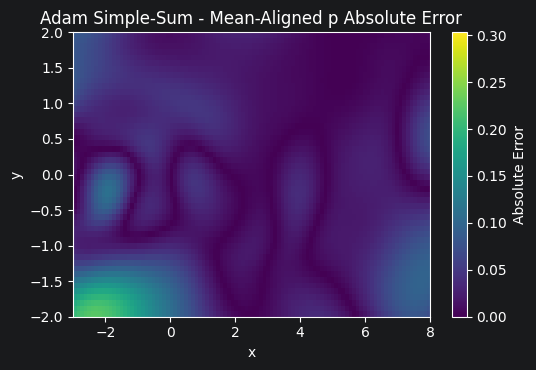

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_simple_sum_p_mean_aligned_absolute_error.png


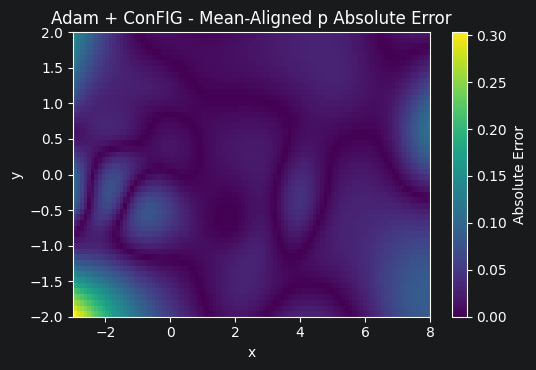

Saved: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config/adam_plus_config_p_mean_aligned_absolute_error.png


In [20]:

p_aligned_pred = {
    method: align_pressure_mean(truth["p"], pred["p"])
    for method, pred in predictions.items()
}

p_aligned_abs = {
    method: np.abs(truth["p"] - pred)
    for method, pred in p_aligned_pred.items()
}

p_aligned_vmax = max(
    np.max(p_aligned_abs["Adam Simple-Sum"]),
    np.max(p_aligned_abs["Adam + ConFIG"]),
)

for method in ["Adam Simple-Sum", "Adam + ConFIG"]:
    plt.figure(figsize=(5.5, 3.8))
    im = plt.imshow(
        p_aligned_abs[method].reshape(GRID_SHAPE),
        extent=EXTENT,
        aspect="auto",
        vmin=0.0,
        vmax=p_aligned_vmax,
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"{method} - Mean-Aligned p Absolute Error")
    plt.colorbar(im, label="Absolute Error")
    plt.tight_layout()

    safe_method = (
        method.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
    )
    out = OUTPUT_DIR / f"{safe_method}_p_mean_aligned_absolute_error.png"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)



## 9. 最终汇总打印

重点查看：

1. `history_summary.csv`：loss / gradient / cosine / conflict。
2. `field_metrics_corrected.csv`：**修正 broadcasting 后**的 u/v/p Relative L2、MAE、Max Absolute Error。
3. 六张 raw Absolute Error 图。
4. 两张 pressure mean-aligned Absolute Error 图。
5. loss / cosine / gradient norm 对比曲线。

正式写实验结论时，优先比较 **Adam Simple-Sum vs Adam + ConFIG**。原始 LBFGS PINNsFormer 可作为额外 reference，但不能用于隔离 ConFIG 的因果贡献。


In [21]:

print("=" * 72)
print("Analysis finished")
print("All outputs saved to:")
print(OUTPUT_DIR.resolve())
print("=" * 72)

print("\nHistory summary:")
display(summary)

print("\nCorrected field metrics:")
display(field_metrics)

print("\nCorrected Relative L2 comparison:")
display(l2_wide)


Analysis finished
All outputs saved to:
/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/comparison_adam_vs_config

History summary:


,Adam Simple-Sum,Adam + ConFIG,ConFIG improvement vs Adam (%)
Final total loss,0.001381,0.001614,-16.894004
Final data loss,0.000966,0.001254,-29.761104
Final physics loss,0.000415,0.000361,13.058842
Min total loss,0.001381,0.001614,-16.894004
Min data loss,0.000966,0.001254,-29.761104
Min physics loss,0.000415,0.000340,18.103378
Mean total loss,0.021243,0.023100,-8.739783
Mean data loss,0.017202,0.020953,-21.805040
Mean physics loss,0.004041,0.002147,46.872907
Final ||g_data||,0.040937,0.103527,NaN



Corrected field metrics:


,Method,Field,Relative L2,MAE,Max Absolute Error,Mean-aligned Relative L2
0,Adam Simple-Sum,u,0.057218,0.031171,0.411395,NaN
1,Adam Simple-Sum,v,0.162706,0.031579,0.174138,NaN
2,Adam Simple-Sum,p,7.115587,0.944240,1.168361,0.354244
3,Adam + ConFIG,u,0.043878,0.026559,0.281162,NaN
4,Adam + ConFIG,v,0.167616,0.033476,0.177705,NaN
5,Adam + ConFIG,p,0.963713,0.120951,0.423981,0.316694



Corrected Relative L2 comparison:


Method,Adam + ConFIG,Adam Simple-Sum,ConFIG improvement vs Adam (%)
Field,,,
p,0.963713,7.115587,86.456317
u,0.043878,0.057218,23.313802
v,0.167616,0.162706,-3.017759
